# 04 - Estudio de mapas y comparación pareada

Comparación de tres mapas y escalado 16/32/64 con cinco repeticiones, usando exactamente los mismos IDs para RBF-SVM y QSVM.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'results/latest_run.json').exists())
latest = json.loads((ROOT / 'results/latest_run.json').read_text(encoding='utf-8'))
RUN = ROOT / latest['path']
study = pd.read_csv(RUN / 'metrics/feature_map_study.csv')
paired = pd.read_csv(RUN / 'metrics/paired_scaling_summary.csv')
display(study.groupby('feature_map').agg(cv_f1_mean=('cv_f1_mean', 'mean'), cv_f1_std=('cv_f1_mean', 'std'), kta=('kernel_target_alignment', 'mean')).round(4))
display(paired.round(4))

,cv_f1_mean,cv_f1_std,kta
feature_map,,,
custom,0.5648,0.0960,0.1832
pauli,0.4532,0.1532,0.1330
zz,0.5521,0.1072,0.1493


,model,feature_map,subset_size,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,false_positive_rate_mean,false_positive_rate_std
0,qsvm_paired,custom,16,0.4735,0.0234,0.5088,0.0249,0.4939,0.0517,0.6520,0.1049
1,qsvm_paired,custom,32,0.4713,0.0474,0.5066,0.0054,0.4888,0.0505,0.6540,0.1984
2,qsvm_paired,custom,64,0.4622,0.0352,0.5071,0.0197,0.5025,0.0504,0.6975,0.1565
3,rbf_svm_paired,NaN,16,0.5009,0.0282,0.5148,0.0172,0.4693,0.0511,0.5485,0.1284
4,rbf_svm_paired,NaN,32,0.5256,0.0169,0.5095,0.0135,0.4159,0.0345,0.4170,0.0591
5,rbf_svm_paired,NaN,64,0.5280,0.0279,0.5186,0.0090,0.4373,0.0342,0.4385,0.1027


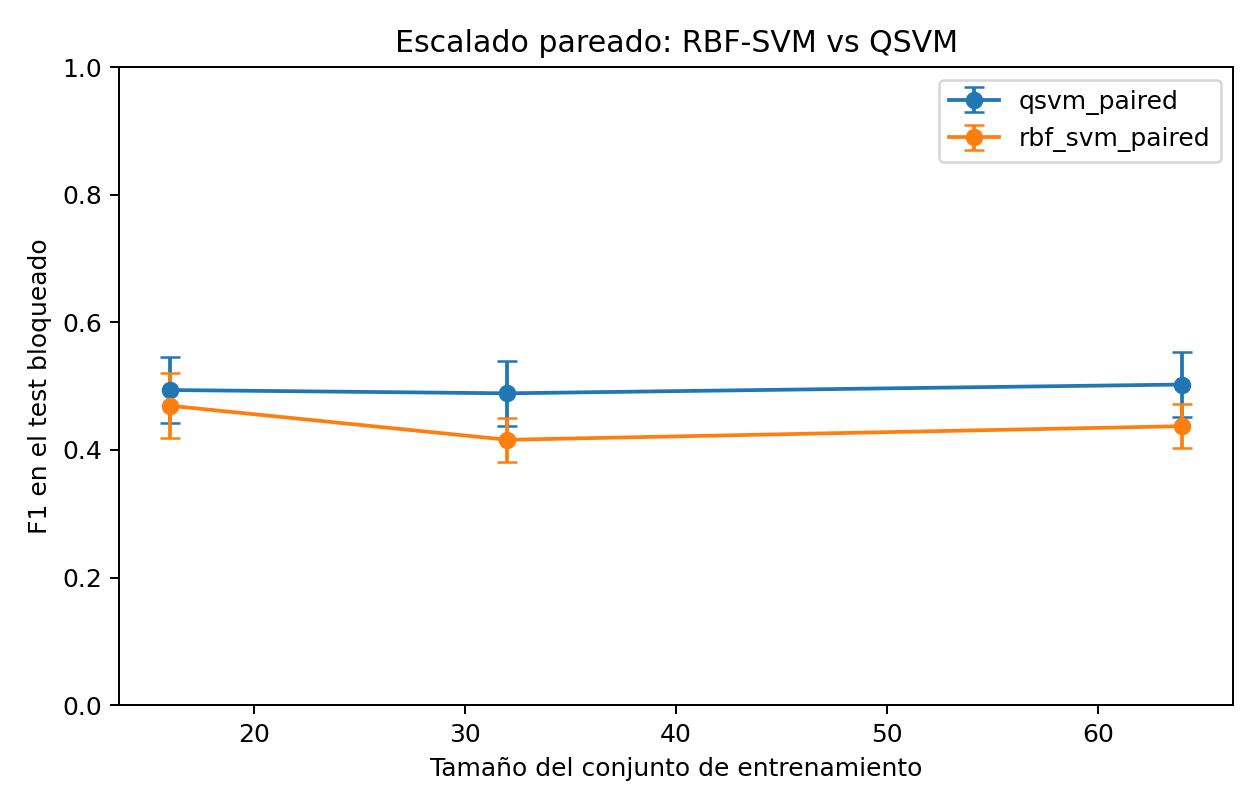

In [2]:
display(Image(filename=str(RUN / 'figures/paired_scaling_f1.png'), width=900))

Conclusión: ambos modelos pareados permanecen cerca del azar en balanced accuracy. La QSVM presenta F1 competitivo solo porque predice la clase potable con mayor frecuencia; su tasa de no potable declarada potable llega a ~0.70 en n=64. No se afirma ventaja cuántica.